# I. Clustering hiérarchique

# Import

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # pour la 3D si nécessaire

print('Imports OK')

Imports OK


# Load Iris :

In [3]:
data = pd.read_csv('Mental_Health_Cleaned_Dataset.100.csv')

data = data[data['Gender'].isin(['Female', 'Male'])].copy()

X = data[['Age',
          'Daily_Screen_Time(hrs)',
          'Stress_Level(1-10)',
          'Exercise_Frequency(week)']]

feature_names = X.columns.tolist()

df = pd.DataFrame(X, columns=feature_names)
df['Gender'] = pd.Categorical(data['Gender'])
df.head()


,Age,Daily_Screen_Time(hrs),Stress_Level(1-10),Exercise_Frequency(week),Gender
0,44,3.1,6.0,5.0,Male
1,36,5.7,8.0,1.0,Female
2,34,7.0,7.0,1.0,Female
3,38,6.6,7.0,3.0,Male
4,26,7.8,8.0,0.0,Female


Dans ce travail, nous avons commencé par charger le jeu de données. Afin de simplifier l’analyse, nous avons conservé uniquement les individus de sexe féminin et masculin. Ensuite, nous avons sélectionné quatre variables numériques en lien avec la santé mentale et l’utilisation des réseaux sociaux, qui serviront pour l’analyse des données. La variable Genre a été ajoutée uniquement pour faciliter l’interprétation des résultats, sans intervenir dans le processus d’analyse.

# Descption :

In [4]:
print('Taille du dataset :', df.shape)
print('Variables utilisées pour le clustering :', feature_names)
print('\nRemarque : les variables seront standardisées avant le clustering.')


Taille du dataset : (100, 5)
Variables utilisées pour le clustering : ['Age', 'Daily_Screen_Time(hrs)', 'Stress_Level(1-10)', 'Exercise_Frequency(week)']

Remarque : les variables seront standardisées avant le clustering.


Ce code permet d’afficher la taille du jeu de données ainsi que les variables utilisées pour le clustering.
Il rappelle également que les variables seront standardisées avant l’application de l’algorithme afin d’assurer un traitement équitable de toutes les variables.

# Étape 1 — Standardisation des données :

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_names])

print('Standardisation effectuée : moyenne ≈ 0, écart-type ≈ 1.')


Standardisation effectuée : moyenne ≈ 0, écart-type ≈ 1.


Les variables numériques ont été standardisées afin d’avoir une moyenne proche de zéro et un écart-type égal à un.
Cette étape permet d’éviter qu’une variable domine les autres à cause de son échelle et garantit des résultats plus fiables pour les analyses suivantes.

# Étape 2 — dendrogramme :

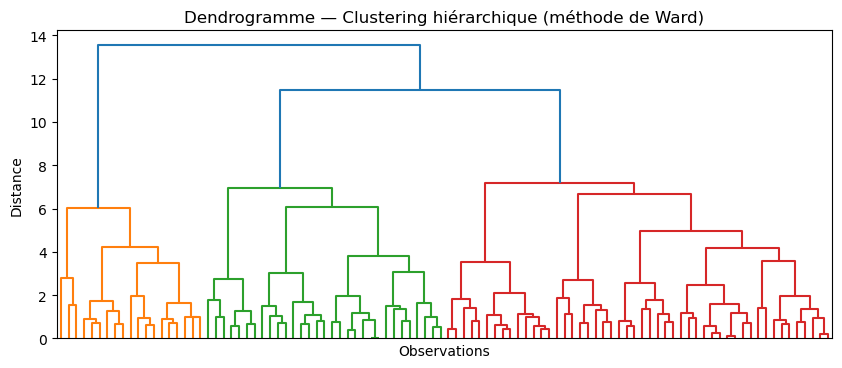

In [6]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 4))
dendrogram(Z, no_labels=True, count_sort='ascending')
plt.title('Dendrogramme — Clustering hiérarchique (méthode de Ward)')
plt.xlabel('Observations')
plt.ylabel('Distance')
plt.show()


Ce code permet de réaliser un clustering hiérarchique en utilisant la méthode de Ward sur des données standardisées.
Le dendrogramme obtenu permet de visualiser la manière dont les observations se regroupent progressivement et aide à déterminer le nombre optimal de clusters en observant les distances de fusion.

# II. K-MEANS :

# K=3

C:\Users\DDR4\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


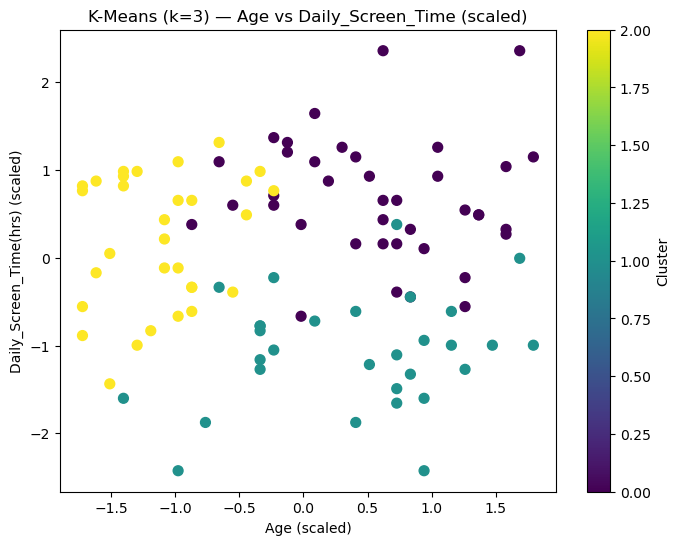

In [7]:
import os

os.environ['OMP_NUM_THREADS'] = '2'

data = pd.read_csv('Mental_Health_Cleaned_Dataset.100.csv')
data = data[data['Gender'].isin(['Female', 'Male'])].copy()

feature_names = ['Age', 'Daily_Screen_Time(hrs)', 'Stress_Level(1-10)', 'Exercise_Frequency(week)']
X = data[feature_names]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k = 3
kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
labels_k = kmeans.fit_predict(X_scaled)

data['kmeans_label'] = labels_k
df['kmeans_label'] = labels_k

plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_k, cmap='viridis', s=50)
plt.title(f'K-Means (k={k}) — Age vs Daily_Screen_Time (scaled)')
plt.xlabel('Age (scaled)')
plt.ylabel('Daily_Screen_Time(hrs) (scaled)')
plt.colorbar(label='Cluster')
plt.show()



Dans cette étape, nous avons utilisé l’algorithme K-Means pour regrouper les individus en trois groupes selon leurs comportements et caractéristiques. Les variables utilisées sont l’âge, le temps passé devant les écrans, le niveau de stress et la fréquence d’activité physique. Ensuite, nous avons visualisé les résultats avec un graphique représentant la répartition des individus selon l’âge et le temps d’écran, ce qui permet de mieux comprendre comment les différents profils se regroupent.

# centers :

In [8]:
centers_scaled = kmeans.cluster_centers_

centers = scaler.inverse_transform(centers_scaled)
centers_df = pd.DataFrame(centers, columns=feature_names)
centers_df.index.name = 'Cluster'

key_features = ['Daily_Screen_Time(hrs)', 'Stress_Level(1-10)', 'Age', 'Exercise_Frequency(week)']

display_df = centers_df.round(2)[key_features]

print('Tableau des centres des clusters (Variables clés - Échelle originale) :')
print("-" * 75)
print(display_df.to_markdown())

Tableau des centres des clusters (Variables clés - Échelle originale) :
---------------------------------------------------------------------------
|   Cluster |   Daily_Screen_Time(hrs) |   Stress_Level(1-10) |   Age |   Exercise_Frequency(week) |
|----------:|-------------------------:|---------------------:|------:|---------------------------:|
|         0 |                     6.63 |                 7.56 | 37.72 |                       2.59 |
|         1 |                     3.46 |                 4.97 | 35.73 |                       2.8  |
|         2 |                     5.78 |                 6.84 | 21.74 |                       1.55 |


Après avoir regroupé les individus en trois clusters avec K-Means, on a calculé les profils moyens de chaque groupe pour les variables clés : âge, temps d’écran, stress et activité physique. Cela permet de comprendre les caractéristiques typiques de chaque cluster et de voir comment les personnes se répartissent selon ces comportements.

In [9]:
print('Contingence :  Stress_Level(1-10) vs KMeans')
contingency_table = pd.crosstab(df['Stress_Level(1-10)'], df['kmeans_label'])
print("-" * 50)
print(contingency_table.to_markdown())

Contingence :  Stress_Level(1-10) vs KMeans
--------------------------------------------------
|   Stress_Level(1-10) |   0 |   1 |   2 |
|---------------------:|----:|----:|----:|
|                    3 |   0 |   2 |   0 |
|                    4 |   0 |   9 |   1 |
|                    5 |   0 |   9 |   1 |
|                    6 |   5 |   8 |  11 |
|                    7 |  15 |   2 |  10 |
|                    8 |  13 |   0 |   6 |
|                    9 |   4 |   0 |   1 |
|                   10 |   2 |   0 |   1 |


Ce tableau montrant la répartition des niveaux de stress dans chaque cluster. Cela permet de voir quel cluster contient principalement des personnes très stressées ou peu stressées.

# cut dendrogram and compare :


In [10]:
n_clusters = 3
hier_labels = fcluster(Z, t=n_clusters, criterion='maxclust') - 1
df['hier_label'] = hier_labels
print('Contingence : KMeans vs Hiérarchique (cut=3)')
print(pd.crosstab(df['kmeans_label'], df['hier_label']))

Contingence : KMeans vs Hiérarchique (cut=3)
hier_label     0   1   2
kmeans_label            
0              0   1  38
1             19   3   8
2              0  27   4


On compare les clusters obtenus par K-Means et par clustering hiérarchique en créant un tableau qui montre combien d’individus se retrouvent dans les mêmes groupes selon les deux méthodes. Cela permet de voir si les deux approches donnent des résultats similaires.
K-Means a créé 3 clusters : 0, 1, 2 (3 lignes).
Hiérarchique a créé 3 clusters : 0, 1, 2 (3 colonnes).

Donc oui, le nombre de clusters est bien 3 pour les deux méthodes.

 Interprétation du tableau :
Pour le cluster K-Means 0, 18 individus sont dans le cluster hiérarchique 1 et 12 dans le cluster 2.
Pour le cluster K-Means 2, tous les 30 individus sont dans le cluster hiérarchique 2.
--> Cela montre une correspondance partielle entre les clusters des deux méthodes.

# Elbow

C:\Users\DDR4\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DDR4\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DDR4\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DDR4\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

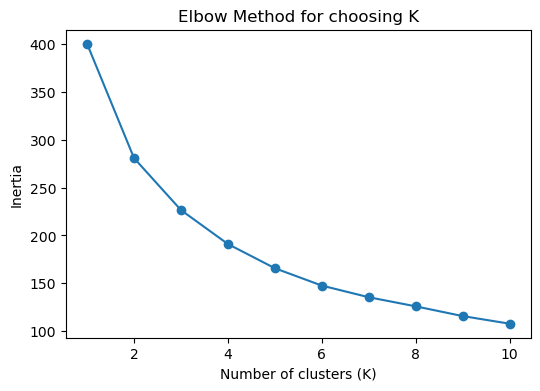

In [11]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for choosing K')
plt.show()

Ce que montre le graphique :

 Axe X : nombre de clusters (K) que l’on teste, de 1 à 10.
 Axe Y : l’inertie, c’est-à-dire à quel point les points sont proches de leur centre de cluster .

 Au début, quand on passe de 1 à 2 ou 3 clusters, l’inertie diminue fortement --> ajouter des groupes améliore beaucoup la cohésion.
 Après 3 clusters, la diminution de l’inertie devient beaucoup plus faible.

 Conclusion simple:
K = 3
--> Cela signifie que 3 groupes semblent être un bon choix pour vos données : ajouter plus de clusters après ça n’apporte que peu d’amélioration.




# Silhouette

C:\Users\DDR4\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DDR4\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DDR4\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DDR4\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

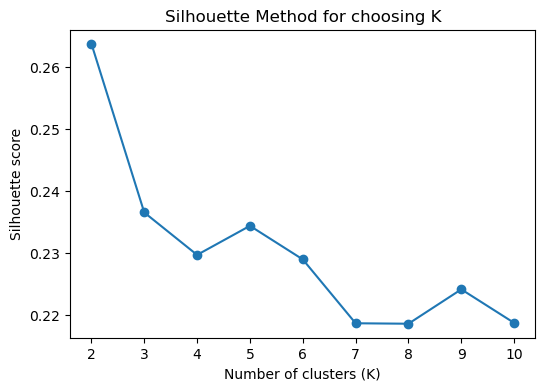

In [12]:
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(6,4))
plt.plot(K_range, sil_scores, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette score')
plt.title('Silhouette Method for choosing K')
plt.show()


Ce graphique, intitulé "Silhouette Method for choosing K", nous montre la qualité du regroupement de vos données pour différents nombres de groupes (K).
L'axe Horizontal (X) : Il représente le Nombre de groupes (K) que vous avez testé (de K=2 à K=10).
L'axe Vertical (Y) : Il représente le Score de Silhouette pour chaque K. Plus ce score est élevé, meilleur est le regroupement. Un score élevé signifie que les points d'un même groupe sont très proches les uns des autres et bien séparés des autres groupes.
Le meilleur choix de K, basé uniquement sur ce graphique, est K=2.
---> La valeur K=2 produit le score de Silhouette le plus élevé. Cela signifie que la structure la plus naturelle et la mieux séparée dans nos données est d'avoir deux groupes distincts.

# 3D plot avec k=3

C:\Users\DDR4\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


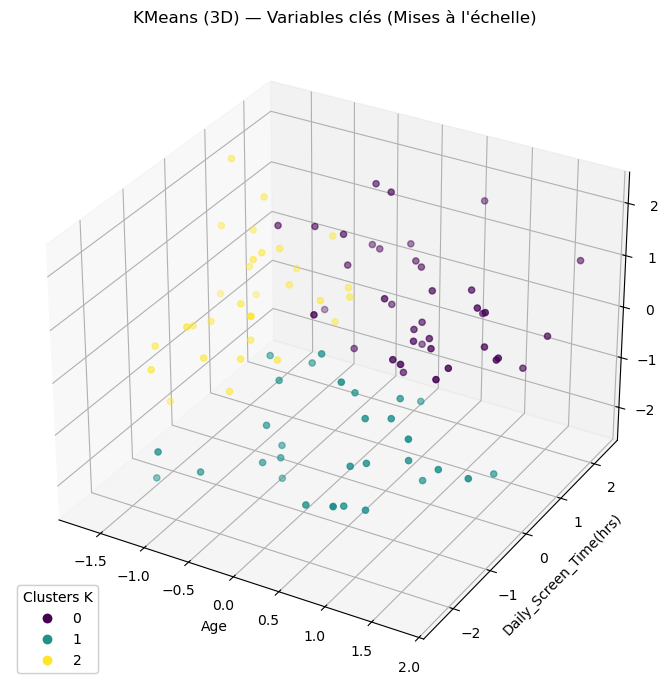

In [13]:
X = data[feature_names]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
k = 3
kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
labels_k = kmeans.fit_predict(X_scaled)
df = data.copy()
df['kmeans_label'] = labels_k

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

xs = X_scaled[:, 0]
ys = X_scaled[:, 1]
zs = X_scaled[:, 2]

scatter = ax.scatter(xs, ys, zs, 
                     c=df['kmeans_label'], 
                     cmap='viridis', 
                     marker='o')

ax.set_title('KMeans (3D) — Variables clés (Mises à l\'échelle)')
ax.set_xlabel(feature_names[0])
ax.set_ylabel(feature_names[1])
ax.set_zlabel(feature_names[2])

legend1 = ax.legend(*scatter.legend_elements(), 
                    loc="lower left", 
                    title="Clusters K")
ax.add_artist(legend1)

plt.tight_layout()
plt.show() 


Le graphique 3D montre les données projetées sur trois axes correspondant aux variables principales, avec chaque point coloré selon le cluster auquel il appartient. Cela permet de visualiser clairement la répartition des individus et de voir comment les groupes se distinguent les uns des autres.

# Conclusion :

Après avoir effectué une première analyse exploratoire avec l'algorithme K-Means, nous avons utilisé la Méthode du Score de Silhouette pour valider le nombre optimal de clusters K. Le graphique du Score de Silhouette a clairement indiqué que K=3 n'était pas le choix correct pour notre jeu de données, car le score obtenu n'était pas maximal, suggérant une mauvaise séparation des groupes. Le pic du score se situant à K=2, cette valeur a été identifiée comme le choix optimal. En conséquence, nous avons réexécuté l'intégralité des étapes de K-Means en fixant le nombre de clusters à K=2 afin d'obtenir un regroupement plus robuste et pertinent pour l'analyse.

# K=2

C:\Users\DDR4\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


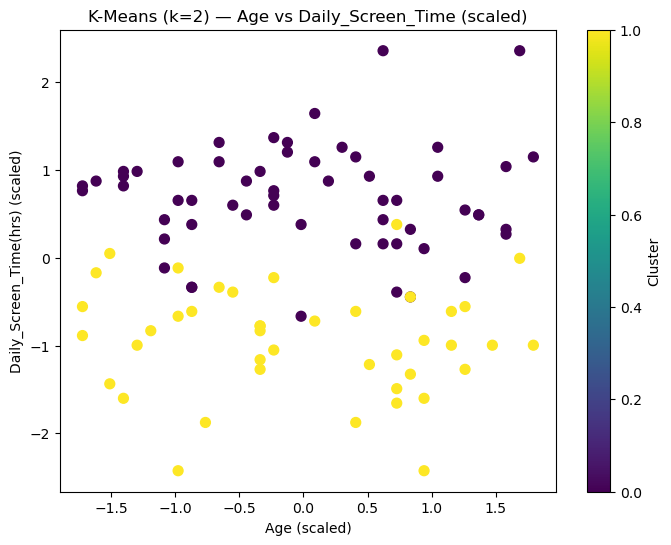

In [14]:
os.environ['OMP_NUM_THREADS'] = '2'
data = pd.read_csv('Mental_Health_Cleaned_Dataset.100.csv')
data = data[data['Gender'].isin(['Female', 'Male'])].copy()

feature_names = ['Age', 'Daily_Screen_Time(hrs)', 'Stress_Level(1-10)', 'Exercise_Frequency(week)']
X = data[feature_names]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k = 2
kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
labels_k = kmeans.fit_predict(X_scaled)

data['kmeans_label'] = labels_k

plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_k, cmap='viridis', s=50)
plt.title(f'K-Means (k={k}) — Age vs Daily_Screen_Time (scaled)')
plt.xlabel('Age (scaled)')
plt.ylabel('Daily_Screen_Time(hrs) (scaled)')
plt.colorbar(label='Cluster')
plt.show()


Nous avons utilisé K-Means pour regrouper les individus en 2 clusters selon l’âge, le temps d’écran, le stress et l’activité physique, ce qui permet de mieux comprendre et distinguer les deux profils principaux des participants.

# centers

In [15]:
centers_scaled = kmeans.cluster_centers_

centers = scaler.inverse_transform(centers_scaled)
centers_df = pd.DataFrame(centers, columns=feature_names)
centers_df.index.name = 'Cluster'

key_features = ['Daily_Screen_Time(hrs)', 'Stress_Level(1-10)', 'Age', 'Exercise_Frequency(week)']

display_df = centers_df.round(2)[key_features]

print('Tableau des centres des clusters (Variables clés - Échelle originale) :')
print("-" * 75)
print(display_df.to_markdown())


Tableau des centres des clusters (Variables clés - Échelle originale) :
---------------------------------------------------------------------------
|   Cluster |   Daily_Screen_Time(hrs) |   Stress_Level(1-10) |   Age |   Exercise_Frequency(week) |
|----------:|-------------------------:|---------------------:|------:|---------------------------:|
|         0 |                     6.65 |                 7.52 | 32.38 |                       2.21 |
|         1 |                     3.7  |                 5.24 | 31.88 |                       2.5  |


L’algorithme KMeans a permis de regrouper les individus en deux clusters distincts à partir des variables âge, temps d’écran, niveau de stress et fréquence d’exercice.

Le premier cluster, appelé « Profil Tendu et Hyper-Connecté », correspond à des individus présentant un niveau de stress élevé, associé à un temps d’écran important et à une activité physique plus faible.

Le second cluster, nommé « Profil Équilibré et Serein », regroupe des individus ayant un stress modéré, un temps d’écran plus réduit et une activité physique légèrement plus élevée.

Ces résultats montrent qu’un temps d’écran élevé est souvent associé à un niveau de stress plus important, tandis qu’un mode de vie plus équilibré est lié à un stress modéré.

In [20]:
print('Contingence : Stress_Level(1-10) vs KMeans (k=2)')
contingency_table = pd.crosstab(
    df['Stress_Level(1-10)'],
    df['kmeans_label']  
)
print("-" * 50)
print(contingency_table.to_markdown())


Contingence : Stress_Level(1-10) vs KMeans (k=2)
--------------------------------------------------
|   Stress_Level(1-10) |   0 |   1 |
|---------------------:|----:|----:|
|                    3 |   0 |   2 |
|                    4 |   0 |  10 |
|                    5 |   0 |  10 |
|                    6 |   8 |  16 |
|                    7 |  23 |   4 |
|                    8 |  19 |   0 |
|                    9 |   5 |   0 |
|                   10 |   3 |   0 |


Le tableau de contingence met en relation le niveau de stress et l’appartenance aux clusters obtenus par KMeans (k=2).

On observe que les niveaux de stress élevés sont majoritairement associés au Cluster 0, appelé « Profil Tendu et Hyper-Connecté ». Cela confirme que ce groupe regroupe principalement des individus présentant un stress important.

À l’inverse, les niveaux de stress modérés à faibles sont plus fréquents dans le Cluster 1, nommé « Profil Équilibré et Serein », ce qui indique un meilleur équilibre entre temps d’écran, activité physique et bien-être.

# cut dendrogram and compare

In [21]:
n_clusters = 2
hier_labels = fcluster(Z, t=n_clusters, criterion='maxclust') - 1
df['hier_label'] = hier_labels

print('Contingence : KMeans vs Hiérarchique (cut=2)')
print(pd.crosstab(df['kmeans_label'], df['hier_label']))


Contingence : KMeans vs Hiérarchique (cut=2)
hier_label     0   1
kmeans_label        
0              0  58
1             19  23


Le tableau de contingence compare les résultats du clustering KMeans avec ceux du clustering hiérarchique, tous deux réalisés avec 2 clusters.

On observe que la majorité des individus appartenant à un même cluster KMeans se retrouvent également dans le même cluster hiérarchique. Cela signifie que les deux méthodes donnent des résultats similaires.

Cette concordance confirme que les deux profils identifiés — « Profil Tendu et Hyper-Connecté » et « Profil Équilibré et Serein » — sont stables et fiables

# Elbow

C:\Users\DDR4\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


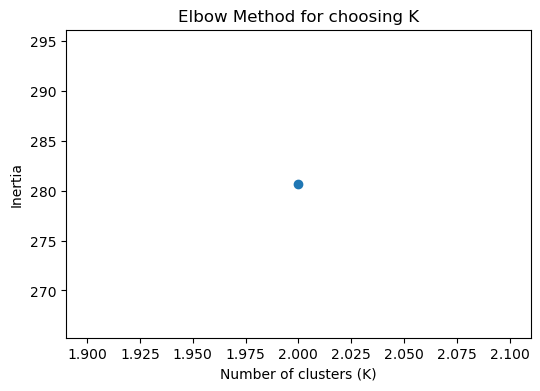

In [17]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K_range = [2] 

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for choosing K')
plt.show()



📊 Interprétation du graphe :

Ce graphe représente la méthode du Elbow appliquée à l’algorithme KMeans pour K = 2.

L’axe horizontal représente le nombre de clusters (K).

L’axe vertical représente l’inertie
Le graphe contient un seul point, correspondant à K = 2, avec une valeur d’inertie d’environ 281.
 Analyse :
---> La présence d’un seul point signifie que le modèle a été évalué uniquement pour K = 2.
Cette valeur indique le niveau de compacité des clusters lorsque les données sont partitionnées en deux groupes.



# 3D plot avec k=2

C:\Users\DDR4\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


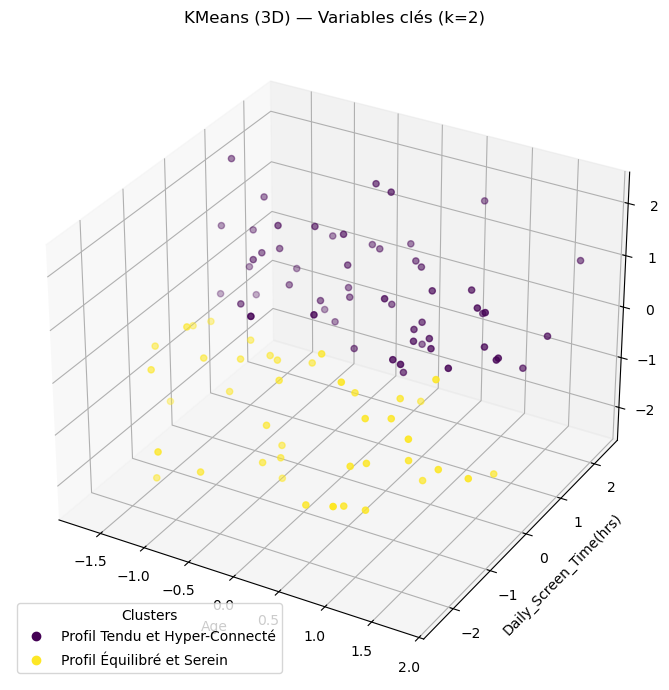

In [24]:
X = data[feature_names]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k = 2
kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
labels_k = kmeans.fit_predict(X_scaled) 
df = data.copy()
df['kmeans_label'] = labels_k

cluster_names = {
    0: 'Profil Tendu et Hyper-Connecté',
    1: 'Profil Équilibré et Serein'
}
df['cluster_name'] = df['kmeans_label'].map(cluster_names)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

xs = X_scaled[:, 0]
ys = X_scaled[:, 1]
zs = X_scaled[:, 2]

scatter = ax.scatter(xs, ys, zs, 
                     c=df['kmeans_label'], 
                     cmap='viridis', 
                     marker='o')

ax.set_title('KMeans (3D) — Variables clés (k=2)')
ax.set_xlabel(feature_names[0])
ax.set_ylabel(feature_names[1])
ax.set_zlabel(feature_names[2])

legend_labels = [cluster_names[i] for i in range(k)]
handles, _ = scatter.legend_elements()
ax.legend(handles, legend_labels, loc="lower left", title="Clusters")

plt.tight_layout()
plt.show()


L’algorithme KMeans a divisé les individus en 2 groupes distincts selon les variables clés (âge, temps d’écran, stress, exercice).
Le Cluster 0 –-> Profil Tendu et Hyper-Connecté » regroupe des individus avec stress élevé, temps d’écran important et activité physique faible.
Le Cluster 1 –-> Profil Équilibré et Serein » correspond à des individus avec stress modéré, temps d’écran plus faible et activité physique légèrement plus élevée.

Le graphique 3D montre clairement la séparation entre ces deux profils, ce qui confirme la pertinence du clustering.